<a href="https://colab.research.google.com/github/OjasTamhankar/AML-Lab/blob/main/exp11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense

In [3]:
vocab_size = 10000
max_length = 200

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

X_train = pad_sequences(X_train, maxlen=max_length)
X_test = pad_sequences(X_test, maxlen=max_length)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
def build_rnn():
    model = Sequential()
    model.add(Embedding(vocab_size, 128, input_length=max_length))
    model.add(SimpleRNN(128))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

In [5]:
def build_lstm():
    model = Sequential()
    model.add(Embedding(vocab_size, 128, input_length=max_length))
    model.add(LSTM(128))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

In [6]:
def build_gru():
    model = Sequential()
    model.add(Embedding(vocab_size, 128, input_length=max_length))
    model.add(GRU(128))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

In [7]:
epochs = 5
batch_size = 64

# Train RNN
rnn_model = build_rnn()
rnn_history = rnn_model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.2)

# Train LSTM
lstm_model = build_lstm()
lstm_history = lstm_model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.2)

# Train GRU
gru_model = build_gru()
gru_history = gru_model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.2)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


313/313 ━━━━━━━━━━━━━━━━━━━━ 46s 139ms/step - accuracy: 0.6169 - loss: 0.6420 - val_accuracy: 0.6348 - val_loss: 0.6356
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 78s 128ms/step - accuracy: 0.7433 - loss: 0.5248 - val_accuracy: 0.7394 - val_loss: 0.5258
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 42s 132ms/step - accuracy: 0.7939 - loss: 0.4405 - val_accuracy: 0.7800 - val_loss: 0.5009
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 42s 134ms/step - accuracy: 0.8368 - loss: 0.3680 - val_accuracy: 0.7572 - val_loss: 0.5445
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 132ms/step - accuracy: 0.8841 - loss: 0.2842 - val_accuracy: 0.8154 - val_loss: 0.4390
Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 149s 469ms/step - accuracy: 0.7852 - loss: 0.4516 - val_accuracy: 0.8590 - val_loss: 0.3383
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 203s 472ms/step - accuracy: 0.8938 - loss: 0.2700 - val_accuracy: 0.8626 - val_loss: 0.3259
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 159s 506ms/step - accuracy: 0.9307 - loss: 0.1870 - val_acc

In [8]:
rnn_acc = rnn_model.evaluate(X_test, y_test)[1]
lstm_acc = lstm_model.evaluate(X_test, y_test)[1]
gru_acc = gru_model.evaluate(X_test, y_test)[1]

print("RNN Accuracy:", rnn_acc)
print("LSTM Accuracy:", lstm_acc)
print("GRU Accuracy:", gru_acc)

782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.8109 - loss: 0.4291
782/782 ━━━━━━━━━━━━━━━━━━━━ 74s 94ms/step - accuracy: 0.8339 - loss: 0.4729
782/782 ━━━━━━━━━━━━━━━━━━━━ 40s 51ms/step - accuracy: 0.8578 - loss: 0.4285
RNN Accuracy: 0.810920000076294
LSTM Accuracy: 0.8338800072669983
GRU Accuracy: 0.8578000068664551


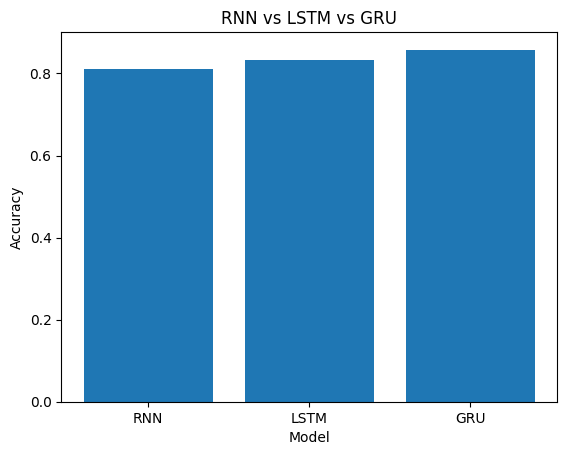

In [9]:
import matplotlib.pyplot as plt

models = ['RNN', 'LSTM', 'GRU']
accuracy = [rnn_acc, lstm_acc, gru_acc]

plt.bar(models, accuracy)
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("RNN vs LSTM vs GRU")
plt.show()